# Librerías (o bibliotecas) de procesamiento de imágenes para Python

En este notebook presentaremos las librerías más usadas para el trabajo con imágenes en Python.

Inicialmente, utilizaremos la libreria matplotlib para mostrar las imágenes en pantalla. Los detalles de esta librería los presentaremos al final de este notebook junto con algunas alternativas.

In [ ]:
import matplotlib.pyplot as plt

Ejecutar el siguiente código para descargar las imágenes de ejemplo que usaremos en el notebook.

Después de ejecutarlo, verificar que existan las imágenes en el directorio local. Si no aparecen, hacer click en el botón "Actualizar" del panel de archivos.

In [ ]:
!rm -fr sample_data
!git clone https://github.com/jmbajo/diplodatos-demo-imgs.git
!mv diplodatos-demo-imgs/* .
!rm -rf diplodatos-demo-imgs

# **imageio**

https://github.com/imageio/imageio

* Interfaz sencilla, muy centrada en lectura/escritura de formatos de imagen y video variados.
* Flexibilidad en formatos y fuentes de datos.
* Funciona sobre numpy.




In [ ]:
import imageio.v3 as iio

# Leer imagen
im1 = iio.imread('morning.jpg')
im2 = iio.imread('imageio:chelsea.png')
im3 = iio.imread('https://yavuzceliker.github.io/sample-images/image-1.jpg')
im3 = iio.imread('3x3.png')

print(type(im3))
print(im3.shape)
print(im3)
print(im3[0])
print(im3[0][0])

plt.imshow(im3)

Para guardar una imagen en disco:

In [ ]:
iio.imwrite("mi_nueva_imagen.png", im3)

## OpenCV

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

img = cv2.imread('sunset.png')

print(type(img))
print(img.shape)

plt.imshow(img)

## Mahotas
https://mahotas.readthedocs.io/en/latest/

In [ ]:
!pip install mahotas

In [ ]:
import numpy as np
import mahotas
from pylab import imshow, show

# loading image
img = mahotas.imread('sunset.png')

print(type(img))
print(img.shape)

## PIL (o Pillow)
https://pillow.readthedocs.io/

In [ ]:
from PIL import Image
import numpy as np

img = Image.open("sunset.png")
im2arr = np.array(img)

print(type(img))
print(type(im2arr))
print(im2arr.shape)

plt.imshow(img)

# Rasterio

In [ ]:
!pip install rasterio

In [ ]:
import rasterio
from rasterio.windows import Window

img_loader = rasterio.open('sample.tif')
print("img_loader.bounds", img_loader.bounds)
print("type(img_loader)", type(img_loader))

print("img_loader.count", img_loader.count)

img_completa = img_loader.read(1)
img_porcion = img_loader.read(1, window=Window(0, 0, 20, 30))


print(type(img_completa))
print(img_completa.shape)
print(img_porcion.shape)

import matplotlib.pyplot as plt
plt.imshow(img_completa)

# Mostrando imágenes con matplotlib




Para mostrar las imágenes con las cuales trabajamos, utilizaremos el método imshow de la librería matplotlib.
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html


In [ ]:
import matplotlib.pyplot as plt
import imageio.v3 as iio

In [ ]:
img = iio.imread('morning.jpg')
plt.imshow(img)

A partir del ejemplo anterior, se puede asumir que el uso del método **imshow()** es simple y directo. Veremos a continuación que debemos tener en cuenta algunas cuestiones no triviales al momento de dibujar una imagen por pantalla. No comprender el funcionamiento de esta librería puede llevarnos a pensar que hay algo mal con nuestro procesamiento cuando no vemos lo que creemos que deberíamos ver. En muchos casos, esto se debe a una mala interpretación del dibujado de la imagen por no comprender como funciona esta librería.

Cada vez que necesitemos mostrar una imagen con **matplotlib** vamos a plantearnos las siguientes dos preguntas muy importantes:


*   ¿Cuál es el tipo de dato del pixel? ¿Es real o entero?
*   ¿Cuantos canales tiene la imagen?

Del resultado de estas dos preguntas, se definirá el comportamiento de la función **imshow()**.





(Avancemos un poco al siguiente NB donde presentamos algunos detalles de la librería numpy)

(Regresamos al notebook sabiendo que una matriz de numpy tiene un tipo asociado y todas las componentes de esa matriz son de ese tipo. Existen múltiples tipos de datos tanto para números reales como enteros)

Abrir las imágenes rose.png y rose_dark.png en un editor de imágenes y compararlas

In [ ]:
rose = iio.imread('rose.png')
rose_dark = iio.imread('rose_dark.png')

# Despues de haber comprendido el tema, probar los ejemplos con estas dos imágenes
# rose = np.array(rose, dtype="float32")
# rose_dark = np.array(rose_dark, dtype="float32")

In [ ]:
print(rose.shape)
print(rose_dark.shape)

In [ ]:
print(rose.dtype)
print(rose_dark.dtype)

In [ ]:
print(rose.min(), rose.max())
print(rose_dark.min(), rose_dark.max())

A partir de lo anterior vemos que ambas imágenes son mono-canal (1 solo canal) y cada pixel es representado por un entero no-signado de 8 bits (valores entre 0 y 255). La imagen "rose_dark", claramente tiene valores más bajos que la imagen original.

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('rose.png')
plt.imshow(rose)

plt.subplot(1, 2, 2)
plt.title('rose_dark.png')
plt.imshow(rose_dark)

plt.show()




Viendo las imágenes deberíamos notar 2 cuestiones.


*   El color no corresponde a escala de grises.
*   La intensidad de las dos imágenes parece ser similar, es decir, las dos imágenes se ven "iguales".

Esto se produce porque la imagen tiene un solo canal, por lo tanto, para **imshow** es simplemente "scalar data" (Asi lo define en su documentación) y no tiene la noción de imagen tal como la conocemos.

Al dibujar una imagen de un solo canal se aplican dos transformaciones que, en general, no queremos: se normalizan los valores y se aplica una tabla de color. A partir de los parámetros cmap, vmin y vmax podemos modificar este comportamiento.

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html

https://matplotlib.org/stable/users/explain/colors/colormaps.html

A modo resumen, podemos completar la siguiente tabla:
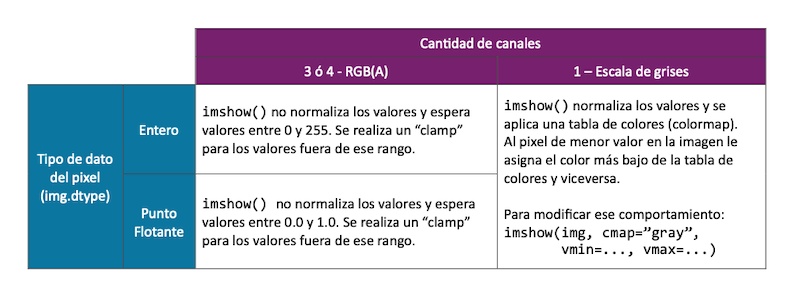

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('rose.png')
plt.imshow(rose, cmap="gray", vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title('rose_dark.png')
plt.imshow(rose_dark, cmap="gray", vmin=0, vmax=255)

plt.show()

In [ ]:
morning = iio.imread('morning.jpg')


print("morning.shape:", morning.shape)
print("morning.dtype:", morning.dtype)

morning_float = np.array(morning, dtype='float64')

print("morning_float.dtype:", morning_float.dtype)

plt.imshow(morning_float / 255.0)


# Mostrando imágenes con plotly

In [ ]:
import plotly.express as px
import numpy as np

# img_rgb = np.array([[[255, 0, 0], [0, 255, 0], [0, 0, 255]],
#                     [[0, 255, 0], [0, 0, 255], [255, 0, 0]]
#                    ], dtype=np.uint8)
fig = px.imshow(np.array(morning[:,:,1], dtype='float32') / 255.0)
fig.show()